# Notebook 00 — Pareto fronts and hypervolume (warmup)

Welcome! For this lab you are a **wet-lab antibody design team**. Each candidate
antibody can be measured for **two properties** we care about, and both are
"higher is better."

The catch: the two properties often **trade off** — pushing one up tends to pull
the other down — so there is no single "best" antibody. Instead we look for a
**set** of strong trade-offs: the **Pareto front**.

Before we touch any Bayesian optimization machinery, this warmup builds the core
intuition on a tiny toy dataset:

1. **dominance** — when is one design strictly better than another?
2. the **non-dominated** set and the **Pareto front**,
3. the **reference point**, and
4. **hypervolume** — a single number summarizing how good a front is.

## Setup

We import a few small helpers and fix the random seed so everyone sees the same
numbers. (These constants are the lab-wide defaults.)

In [1]:
import torch

from mobo_lab import config, metrics, plotting, seed

seed.set_all_seeds(config.SEED)

print("seed:", config.SEED)
print("reference point:", config.REF_POINT)

seed: 123
reference point: [-0.05, -0.05]


## A tiny dataset

Six candidate antibodies, each with two scores (objective 1, objective 2). Think
of objective 1 as "binding-like" and objective 2 as "stability-like." Let's plot
them in **objective space**.

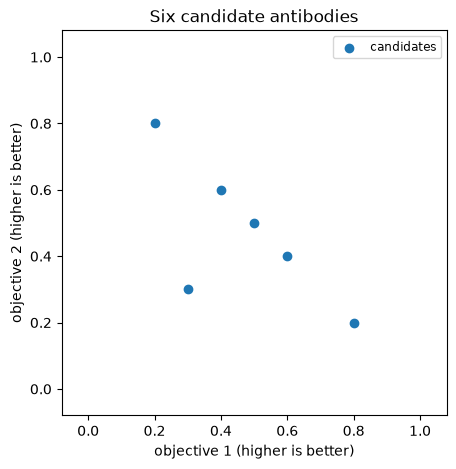

In [2]:
Y_toy = torch.tensor(
    [
        [0.2, 0.8],
        [0.4, 0.6],
        [0.6, 0.4],
        [0.8, 0.2],
        [0.5, 0.5],
        [0.3, 0.3],
    ],
    dtype=torch.double,
)

plotting.plot_objective_space(Y_toy, title="Six candidate antibodies");

## Dominance and the non-dominated set

Design **A dominates** design **B** if A is at least as good as B on *both*
objectives and strictly better on *at least one*. A point is **non-dominated**
(Pareto-optimal) if no other point dominates it.

**Try it first:** looking at the scatter above, which point(s) do you think are
*dominated*? Jot down your guess, then run the next cell to check.

candidate 0: [0.2, 0.8]  ->  non-dominated
candidate 1: [0.4, 0.6]  ->  non-dominated
candidate 2: [0.6, 0.4]  ->  non-dominated
candidate 3: [0.8, 0.2]  ->  non-dominated
candidate 4: [0.5, 0.5]  ->  non-dominated
candidate 5: [0.3, 0.3]  ->  DOMINATED


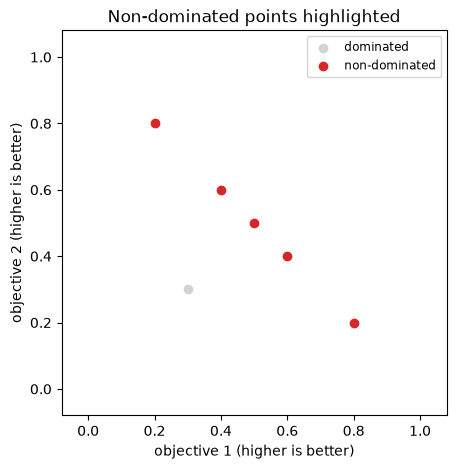

In [3]:
pareto_mask = metrics.compute_pareto_mask(Y_toy)

for i, (point, nd) in enumerate(zip(Y_toy.tolist(), pareto_mask.tolist())):
    label = "non-dominated" if nd else "DOMINATED"
    print(f"candidate {i}: {point}  ->  {label}")

plotting.plot_objective_space(
    Y_toy, pareto_mask=pareto_mask, title="Non-dominated points highlighted"
);

Notice that `(0.5, 0.5)` is **non-dominated**: although it looks "average," no
single other point beats it on *both* axes (each of the corner points is worse on
one objective). Only `(0.3, 0.3)` is dominated. This is the heart of
multi-objective thinking — "best" is a *set*, not a point.

## Hypervolume: scoring a whole front with one number

To compare two fronts we need a single score. **Hypervolume (HV)** is the area
(in 2-D) dominated by our points, measured relative to a **reference point** that
is worse than anything we care about. A bigger dominated region ⇒ a better front.

hypervolume (ref=[-0.05, -0.05]): 0.4925


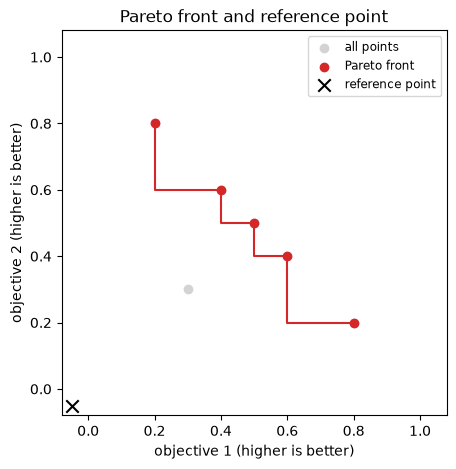

In [4]:
ref_point = config.REF_POINT  # [-0.05, -0.05], just below every objective value

hv = metrics.compute_hypervolume(Y_toy, ref_point)
print(f"hypervolume (ref={ref_point}): {hv:.4f}")

plotting.plot_pareto_front(
    Y_toy, ref_point=ref_point, title="Pareto front and reference point"
);

## The reference point matters

Hypervolume is always measured *relative to* the reference point. Move the
reference point and the number changes — a more pessimistic (more negative)
reference point counts a larger dominated region.

In [5]:
for rp in ([0.0, 0.0], [-0.05, -0.05], [-0.5, -0.5]):
    print(f"ref={rp}  ->  HV={metrics.compute_hypervolume(Y_toy, rp):.4f}")

ref=[0.0, 0.0]  ->  HV=0.4100
ref=[-0.05, -0.05]  ->  HV=0.4925
ref=[-0.5, -0.5]  ->  HV=1.4600


The reference point is a modeling choice: pick it **once**, worse than any
meaningful objective value, and keep it fixed so HV is comparable across rounds.

## Does adding a candidate help?

Adding a new design only increases hypervolume if it is **non-dominated** (it
reaches a part of objective space the front did not already cover). A dominated
new point leaves HV unchanged.

In [6]:
hv_before = metrics.compute_hypervolume(Y_toy, ref_point)

# A strong new candidate that pushes the front outward...
Y_better = torch.cat([Y_toy, torch.tensor([[0.9, 0.9]], dtype=torch.double)])
hv_better = metrics.compute_hypervolume(Y_better, ref_point)

# ...versus a weak one that is already dominated.
Y_worse = torch.cat([Y_toy, torch.tensor([[0.1, 0.1]], dtype=torch.double)])
hv_worse = metrics.compute_hypervolume(Y_worse, ref_point)

print(f"HV before:                 {hv_before:.4f}")
print(f"HV after adding (0.9,0.9): {hv_better:.4f}   (non-dominated -> HV grows)")
print(f"HV after adding (0.1,0.1): {hv_worse:.4f}   (dominated     -> HV unchanged)")

assert hv_better > hv_before
assert hv_worse == hv_before

HV before:                 0.4925
HV after adding (0.9,0.9): 0.9025   (non-dominated -> HV grows)
HV after adding (0.1,0.1): 0.4925   (dominated     -> HV unchanged)


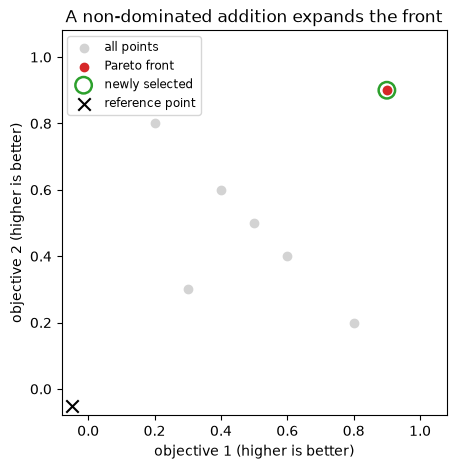

In [7]:
selected = torch.zeros(Y_better.shape[0], dtype=torch.bool)
selected[-1] = True  # the newly added (0.9, 0.9)
plotting.plot_pareto_front(
    Y_better,
    selected_mask=selected,
    ref_point=ref_point,
    title="A non-dominated addition expands the front",
);

## Takeaways

- **Dominance:** A beats B only if it is ≥ on every objective and > on one.
- **Non-dominated set / Pareto front:** the designs no other design beats — the
  trade-offs worth keeping.
- **Reference point:** a fixed, pessimistic anchor for scoring.
- **Hypervolume:** one number for the quality of a whole front; it grows exactly
  when we discover genuinely new, non-dominated trade-offs.

Next, we'll use these ideas to run one real round of batch Bayesian optimization:
fit a model, score candidates, pick a batch, and watch the hypervolume move.